In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import gamma
from glob import glob

In [2]:
era5_out_dir = 'era5_out/'

In [3]:
# files = glob(era5_out_dir + 'era5_*.nc')
# print(f"Found {len(files)} files:")
# for f in files:
#     print(f)

with open(era5_out_dir + 'era5_sl_1950_01.nc', 'rb') as f:
    header = f.read(4)
    print(header) 

b'PK\x03\x04'


In [4]:
# import zipfile, glob, os

# for fpath in sorted(glob.glob(era5_out_dir + 'era5_sl_*.nc')):
#     with open(fpath, 'rb') as f:
#         header = f.read(4)
#     if header != b'PK\x03\x04':
#         continue
    
#     stem = os.path.splitext(os.path.basename(fpath))[0]  # e.g. 'era5_sl_1950_01'
    
#     with zipfile.ZipFile(fpath, 'r') as z:
#         for inner in z.namelist():
#             if 'oper' in inner:
#                 tag = 'oper'
#             elif 'wave' in inner:
#                 tag = 'wave'
#             else:
#                 tag = 'other'
            
#             out_name = f"{stem}_{tag}.nc"
#             out_path = os.path.join(era5_out_dir, out_name)
            
#             with z.open(inner) as src, open(out_path, 'wb') as dst:
#                 dst.write(src.read())
            
#             print(f"Extracted: {out_name}")

In [5]:
# Atmospheric variables (u10, v10, msl, etc.)
ds_oper = xr.open_mfdataset(
    era5_out_dir + 'era5_sl_*_oper.nc',
    combine='by_coords',
    engine='netcdf4'
)

# Wave variables (swh, mwd, mwp, etc.)
ds_wave = xr.open_mfdataset(
    era5_out_dir + 'era5_sl_*_wave.nc',
    combine='by_coords',
    engine='netcdf4'
)

print(ds_oper)
print(ds_wave)

<xarray.Dataset> Size: 3GB
Dimensions:     (valid_time: 666216, latitude: 17, longitude: 17)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5MB 1950-01-01 ... 2025-12-31T23:...
    expver      (valid_time) <U4 11MB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 136B 61.5 61.25 61.0 ... 58.0 57.75 57.5
  * longitude   (longitude) float64 136B 0.0 0.25 0.5 0.75 ... 3.25 3.5 3.75 4.0
    number      int64 8B 0
Data variables:
    u10         (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    u100        (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v100        (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centre

In [6]:
ds = xr.merge([ds_oper, ds_wave])

/tmp/ipykernel_188878/1461857965.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_188878/1461857965.py:1: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  ds = xr.merge([ds_oper, ds_wave])
/tmp/ipykernel_188878/1461857965.py:1: FutureWarning: In a future version of xarray the default value fo

In [7]:
print(ds)

<xarray.Dataset> Size: 5GB
Dimensions:     (valid_time: 666216, latitude: 17, longitude: 17)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 5MB 1950-01-01 ... 2025-12-31T23:...
    expver      (valid_time) <U4 11MB dask.array<chunksize=(744,), meta=np.ndarray>
  * latitude    (latitude) float64 136B 57.5 57.75 58.0 ... 61.0 61.25 61.5
  * longitude   (longitude) float64 136B 0.0 0.25 0.5 0.75 ... 3.25 3.5 3.75 4.0
    number      int64 8B 0
Data variables:
    u10         (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    u100        (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    v100        (valid_time, latitude, longitude) float32 770MB dask.array<chunksize=(744, 17, 17), meta=np.ndarray>
    swh         (valid_time, latitude, longitude) float32 770

In [8]:
print(list(ds.data_vars))

['u10', 'v10', 'u100', 'v100', 'swh', 'pp1d']


56.5110° N, 3.5156° E

In [9]:
target_long = 56.5110
target_lat = 4.5156

In [10]:
ds_point = ds.sel(latitude=target_lat, longitude=target_long, method='nearest')

In [11]:
u10 = ds_point['u10'].values
v10 = ds_point['v10'].values
w = np.sqrt(u10**2 + v10**2)

Hs = ds_point['swh'].values
Tp = ds_point['pp1d'].values

time = ds_point['valid_time'].values

In [12]:
df = pd.DataFrame({
    'time': time,
    'W': w,
    'Hs': Hs,
    'Tp': Tp
})


In [13]:
df = df.set_index('time')

In [14]:
df.head(10)

,W,Hs,Tp
time,,,
1950-01-01 00:00:00,11.691961,2.355734,6.862648
1950-01-01 01:00:00,11.442698,2.351378,6.868996
1950-01-01 02:00:00,10.812086,2.295818,6.871925
1950-01-01 03:00:00,10.466267,2.217788,6.862648
1950-01-01 04:00:00,9.631907,2.119399,6.844582
1950-01-01 05:00:00,9.047784,2.023943,6.811867
1950-01-01 06:00:00,9.502533,1.937388,6.765968
1950-01-01 07:00:00,8.728624,1.861219,6.704933
1950-01-01 08:00:00,8.100243,1.784611,6.625343


In [15]:
print(f"Total records: {len(df)}")
print(f"Dates range: {df.index.min()} to {df.index.max()}")

Total records: 666216
Dates range: 1950-01-01 00:00:00 to 2025-12-31 23:00:00


In [16]:
df.isna().sum()

W     0
Hs    0
Tp    0
dtype: int64

In [17]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 666216 entries, 1950-01-01 00:00:00 to 2025-12-31 23:00:00
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   W       666216 non-null  float32
 1   Hs      666216 non-null  float32
 2   Tp      666216 non-null  float32
dtypes: float32(3)
memory usage: 12.7 MB


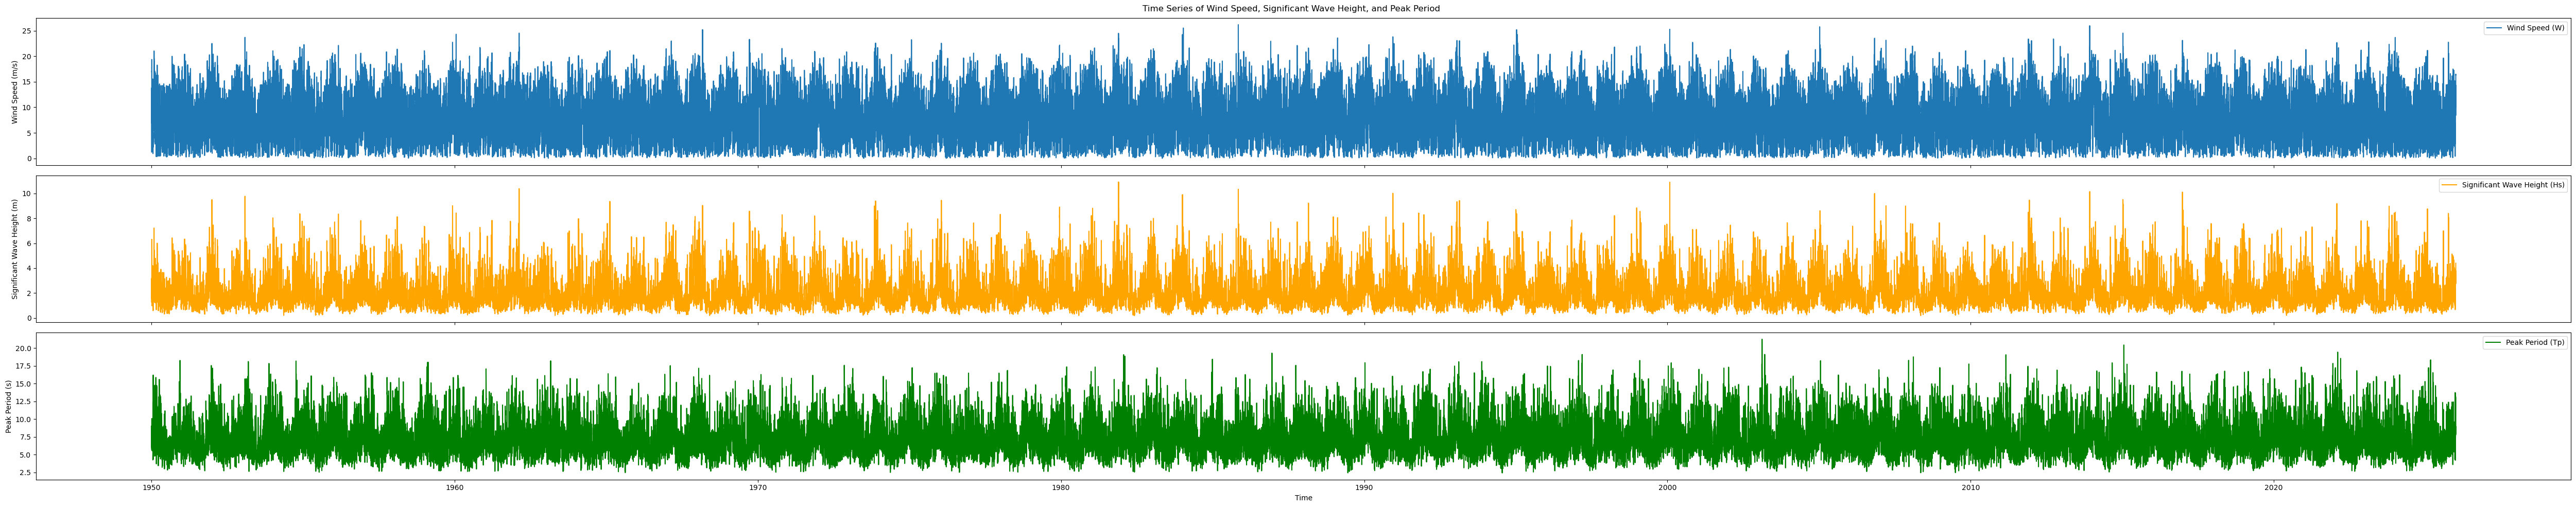

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(50, 10), sharex=True)
axes[0].plot(df.index, df['W'], label='Wind Speed (W)')
axes[0].set_ylabel('Wind Speed (m/s)')
axes[0].legend()
axes[1].plot(df.index, df['Hs'], label='Significant Wave Height (Hs)', color='orange')
axes[1].set_ylabel('Significant Wave Height (m)')
axes[1].legend()        
axes[2].plot(df.index, df['Tp'], label='Peak Period (Tp)', color='green')
axes[2].set_ylabel('Peak Period (s)')
axes[2].legend()
plt.xlabel('Time')
plt.suptitle('Time Series of Wind Speed, Significant Wave Height, and Peak Period')
plt.tight_layout()
plt.show()

In [19]:
from scipy.special import gamma as gamma_func
from scipy.optimize import fsolve

def weibull_mom_equations(params, mean_obs, var_obs):
    """
    Equations to solve for Weibull parameters using method of moments.
    We want: theoretical mean = observed mean
             theoretical variance = observed variance
    """
    alpha, beta = params
    
    # Theoretical mean of Weibull
    mean_theory = beta * gamma_func(1 + 1/alpha)
    
    # Theoretical variance of Weibull
    var_theory = beta**2 * (gamma_func(1 + 2/alpha) - gamma_func(1 + 1/alpha)**2)
    
    # Return the difference - solver will find where this equals zero
    return [mean_theory - mean_obs, var_theory - var_obs]

# Compute observed mean and variance of W
mean_W = df['W'].mean()
var_W = df['W'].var()

print(f"Observed mean wind speed: {mean_W:.3f} m/s")
print(f"Observed variance of wind speed: {var_W:.3f} m²/s²")

# Solve for alpha and beta
# Initial guess: alpha=2, beta=mean (reasonable starting point for wind)
initial_guess = [2.0, mean_W]
alpha_W, beta_W = fsolve(weibull_mom_equations, initial_guess, 
                          args=(mean_W, var_W))

print(f"\nFitted Weibull parameters:")
print(f"  Shape (alpha): {alpha_W:.4f}")
print(f"  Scale (beta):  {beta_W:.4f} m/s")
print(f"\nJohannessen found: alpha=1.708, beta=8.426 (Northern North Sea)")
print(f"Difference is expected - your location is different")

Observed mean wind speed: 8.350 m/s
Observed variance of wind speed: 14.268 m²/s²

Fitted Weibull parameters:
  Shape (alpha): 2.3495
  Scale (beta):  9.4224 m/s

Johannessen found: alpha=1.708, beta=8.426 (Northern North Sea)
Difference is expected - your location is different


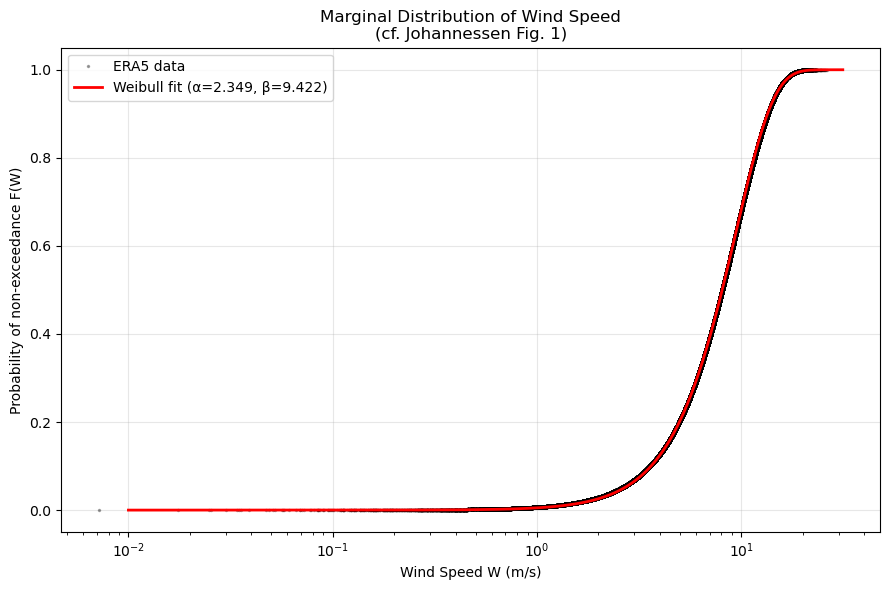


Estimated 100-year wind speed: 28.7 m/s
Johannessen found 39.0 m/s for Northern North Sea


In [20]:
def weibull_cdf(w, alpha, beta):
    """Compute Weibull CDF at values w"""
    return 1 - np.exp(-(w / beta)**alpha)

# Sort your observed W values to get the empirical CDF
W_sorted = np.sort(df['W'].values)
# Empirical CDF: the i-th sorted value has probability i/n of being exceeded
n = len(W_sorted)
empirical_cdf = np.arange(1, n+1) / n

# Theoretical CDF from your fitted Weibull
W_range = np.linspace(0.01, W_sorted.max() * 1.2, 500)
theoretical_cdf = weibull_cdf(W_range, alpha_W, beta_W)

# Plot - match Johannessen Figure 1 style
fig, ax = plt.subplots(figsize=(9, 6))

# Plot on log scale for x-axis (common for wind speed distributions)
ax.semilogx(W_sorted, empirical_cdf, 'ko', markersize=1.5, 
            alpha=0.3, label='ERA5 data')
ax.semilogx(W_range, theoretical_cdf, 'r-', linewidth=2, 
            label=f'Weibull fit (α={alpha_W:.3f}, β={beta_W:.3f})')

ax.set_xlabel('Wind Speed W (m/s)')
ax.set_ylabel('Probability of non-exceedance F(W)')
ax.set_title('Marginal Distribution of Wind Speed\n(cf. Johannessen Fig. 1)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('weibull_wind_fit.png', dpi=150)
plt.show()

# Quantify goodness of fit
# The fitted distribution should lie close to the data points
# Pay special attention to the upper tail (high wind speeds)
# because that is what drives your 100-year extreme

# Estimate 100-year wind speed from your fitted distribution
# 100-year return period at hourly resolution:
# Probability of exceedance per hour = 1 / (100 * 8766)
p_100yr = 1 / (100 * 8766)
# Find W such that 1 - F(W) = p_100yr, i.e. F(W) = 1 - p_100yr
W_100yr = beta_W * (-np.log(p_100yr))**(1/alpha_W)
print(f"\nEstimated 100-year wind speed: {W_100yr:.1f} m/s")
print(f"Johannessen found 39.0 m/s for Northern North Sea")

In [21]:
# Define wind speed bins
# Width of 2 m/s is typical - adjust based on your data range
W_max = df['W'].max()
bin_edges = np.arange(0, W_max + 2, 2)  # 0-2, 2-4, 4-6, ...
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # midpoint of each bin

print(f"Wind speed range: 0 to {W_max:.1f} m/s")
print(f"Number of bins: {len(bin_edges)-1}")

# Fit Weibull to Hs within each wind speed bin
alpha_Hs_list = []
beta_Hs_list = []
W_bin_centers_used = []
n_per_bin = []

for i in range(len(bin_edges)-1):
    w_low = bin_edges[i]
    w_high = bin_edges[i+1]
    
    # Select Hs values where W falls in this bin
    mask = (df['W'] >= w_low) & (df['W'] < w_high)
    Hs_in_bin = df.loc[mask, 'Hs'].values
    
    # Need at least ~50 points to fit a distribution reliably
    if len(Hs_in_bin) < 50:
        print(f"  Bin {w_low:.0f}-{w_high:.0f} m/s: only {len(Hs_in_bin)} points, skipping")
        continue
    
    # Fit 2-parameter Weibull using method of moments
    mean_Hs = Hs_in_bin.mean()
    var_Hs = Hs_in_bin.var()
    
    try:
        alpha_h, beta_h = fsolve(weibull_mom_equations, 
                                  [2.0, mean_Hs], 
                                  args=(mean_Hs, var_Hs))
        
        # Check the fit is physically reasonable
        if alpha_h > 0 and beta_h > 0:
            alpha_Hs_list.append(alpha_h)
            beta_Hs_list.append(beta_h)
            W_bin_centers_used.append(bin_centers[i])
            n_per_bin.append(len(Hs_in_bin))
            print(f"  Bin {w_low:.0f}-{w_high:.0f} m/s: "
                  f"n={len(Hs_in_bin)}, α={alpha_h:.3f}, β={beta_h:.3f}")
    except:
        print(f"  Bin {w_low:.0f}-{w_high:.0f} m/s: fitting failed")

# Convert to arrays
W_bin_centers_used = np.array(W_bin_centers_used)
alpha_Hs_arr = np.array(alpha_Hs_list)
beta_Hs_arr = np.array(beta_Hs_list)

Wind speed range: 0 to 26.2 m/s
Number of bins: 14
  Bin 0-2 m/s: n=19122, α=1.922, β=1.094
  Bin 2-4 m/s: n=65757, α=2.002, β=1.146
  Bin 4-6 m/s: n=109777, α=2.266, β=1.310
  Bin 6-8 m/s: n=133658, α=2.788, β=1.616
  Bin 8-10 m/s: n=124892, α=3.580, β=2.064
  Bin 10-12 m/s: n=96139, α=4.619, β=2.669
  Bin 12-14 m/s: n=63043, α=5.776, β=3.441
  Bin 14-16 m/s: n=34411, α=6.778, β=4.355
  Bin 16-18 m/s: n=14129, α=7.595, β=5.393
  Bin 18-20 m/s: n=4286, α=7.854, β=6.604
  Bin 20-22 m/s: n=854, α=7.345, β=7.955
  Bin 22-24 m/s: n=129, α=7.126, β=9.065
  Bin 24-26 m/s: only 18 points, skipping
  Bin 26-28 m/s: only 1 points, skipping


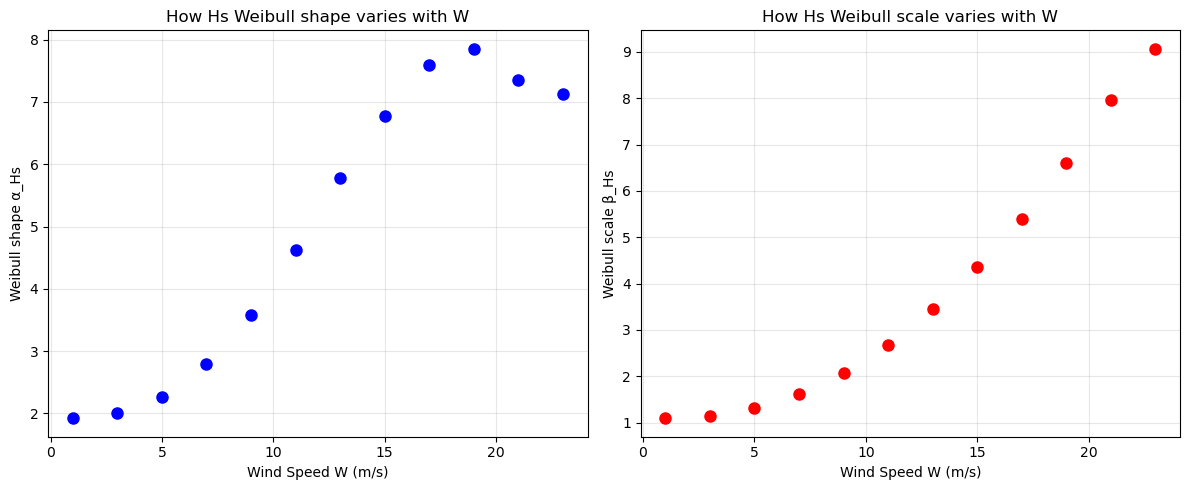

Fitted smooth functions for Hs Weibull parameters:
  alpha_Hs(W) = 0.4878 * W^0.8699 + 0.8286
  beta_Hs(W)  = 0.0112 * W^2.1056 + 0.9948


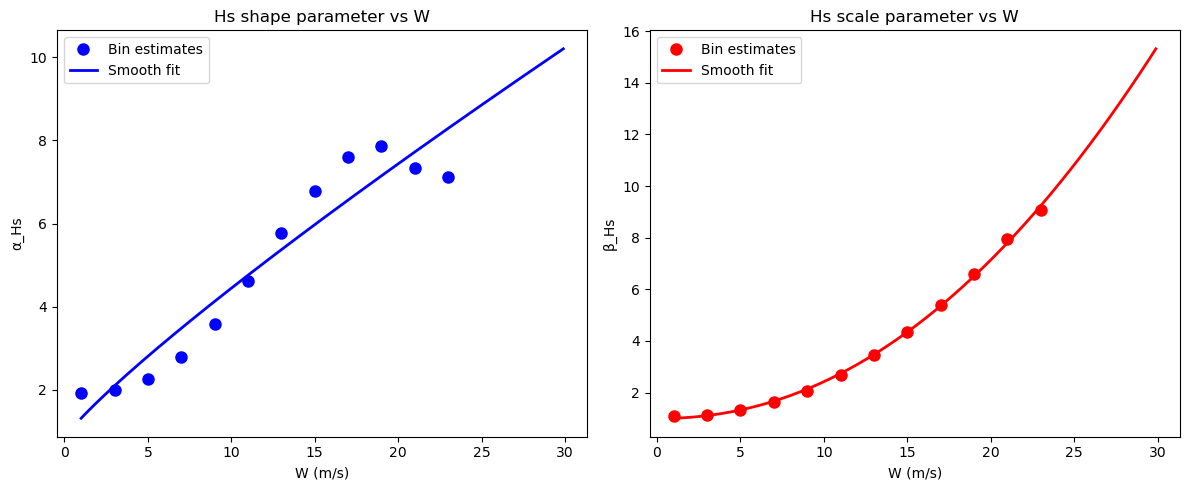

In [22]:
# Fit smooth function: how does alpha_Hs vary with W?
# Try a simple power law: alpha(W) = c1 * W^c2 + c3
# Or a linear model - plot first to see the shape

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(W_bin_centers_used, alpha_Hs_arr, 'bo', markersize=8, label='Bin estimates')
axes[0].set_xlabel('Wind Speed W (m/s)')
axes[0].set_ylabel('Weibull shape α_Hs')
axes[0].set_title('How Hs Weibull shape varies with W')
axes[0].grid(True, alpha=0.3)

axes[1].plot(W_bin_centers_used, beta_Hs_arr, 'ro', markersize=8, label='Bin estimates')
axes[1].set_xlabel('Wind Speed W (m/s)')
axes[1].set_ylabel('Weibull scale β_Hs')
axes[1].set_title('How Hs Weibull scale varies with W')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('conditional_Hs_params.png', dpi=150)
plt.show()

# Based on what you see in the plot, choose an appropriate function
# Power law is a common choice:

def power_law(W, c1, c2, c3):
    return c1 * W**c2 + c3

# Fit alpha_Hs(W)
popt_alpha, _ = curve_fit(power_law, W_bin_centers_used, alpha_Hs_arr, 
                           p0=[1, 0.5, 0.5], maxfev=10000)

# Fit beta_Hs(W)  
popt_beta, _ = curve_fit(power_law, W_bin_centers_used, beta_Hs_arr, 
                          p0=[0.1, 1.5, 0.0], maxfev=10000)

print("Fitted smooth functions for Hs Weibull parameters:")
print(f"  alpha_Hs(W) = {popt_alpha[0]:.4f} * W^{popt_alpha[1]:.4f} + {popt_alpha[2]:.4f}")
print(f"  beta_Hs(W)  = {popt_beta[0]:.4f} * W^{popt_beta[1]:.4f} + {popt_beta[2]:.4f}")

# Define functions you will reuse later
def alpha_Hs_func(W):
    return power_law(W, *popt_alpha)

def beta_Hs_func(W):
    return power_law(W, *popt_beta)

# Plot the smooth fits over your bin estimates
W_plot = np.linspace(W_bin_centers_used.min(), W_bin_centers_used.max() * 1.3, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(W_bin_centers_used, alpha_Hs_arr, 'bo', label='Bin estimates', markersize=8)
axes[0].plot(W_plot, alpha_Hs_func(W_plot), 'b-', linewidth=2, label='Smooth fit')
axes[0].set_xlabel('W (m/s)'); axes[0].set_ylabel('α_Hs'); axes[0].legend()
axes[0].set_title('Hs shape parameter vs W')

axes[1].plot(W_bin_centers_used, beta_Hs_arr, 'ro', label='Bin estimates', markersize=8)
axes[1].plot(W_plot, beta_Hs_func(W_plot), 'r-', linewidth=2, label='Smooth fit')
axes[1].set_xlabel('W (m/s)'); axes[1].set_ylabel('β_Hs'); axes[1].legend()
axes[1].set_title('Hs scale parameter vs W')

plt.tight_layout()
plt.savefig('Hs_smooth_params.png', dpi=150)
plt.show()

In [23]:
def F_Hs_given_W(h, w):
    """
    CDF of Hs given W: probability that wave height <= h when wind speed is w
    Uses the fitted smooth Weibull parameters
    """
    alpha = alpha_Hs_func(w)
    beta = beta_Hs_func(w)
    return 1 - np.exp(-(h / beta)**alpha)

def f_Hs_given_W(h, w):
    """
    PDF of Hs given W (probability density, used for plotting/verification)
    """
    alpha = alpha_Hs_func(w)
    beta = beta_Hs_func(w)
    return (alpha / beta) * (h / beta)**(alpha - 1) * np.exp(-(h / beta)**alpha)

In [24]:
# For each wind speed bin, further bin by Hs and fit Lognormal to Tp

# We will store fitted Lognormal parameter functions for each W bin
lognormal_params = {}  # key = W bin center, value = dict of fitted coefficients

for i, w_center in enumerate(W_bin_centers_used):
    w_low = bin_edges[i] if i < len(bin_edges)-1 else w_center - 1
    # Recalculate bin edges for this wind bin
    # (Use the same binning as before)
    w_low_val = w_center - 1.0  # approximate half-bin width
    w_high_val = w_center + 1.0
    
    # Select data in this wind bin
    mask_w = (df['W'] >= w_low_val) & (df['W'] < w_high_val)
    df_wind_bin = df[mask_w]
    
    if len(df_wind_bin) < 100:
        continue
    
    # Now bin by Hs within this wind bin
    Hs_max_in_bin = df_wind_bin['Hs'].max()
    Hs_bin_edges = np.arange(0, Hs_max_in_bin + 1.0, 1.0)  # 1m bins
    Hs_bin_centers = (Hs_bin_edges[:-1] + Hs_bin_edges[1:]) / 2
    
    mu_lnTp_list = []
    var_lnTp_list = []
    Hs_centers_used = []
    
    for j in range(len(Hs_bin_edges)-1):
        h_low = Hs_bin_edges[j]
        h_high = Hs_bin_edges[j+1]
        
        mask_h = (df_wind_bin['Hs'] >= h_low) & (df_wind_bin['Hs'] < h_high)
        Tp_in_cell = df_wind_bin.loc[mask_h, 'Tp'].values
        
        if len(Tp_in_cell) < 30:
            continue
        
        # Compute mean and variance of ln(Tp)
        lnTp = np.log(Tp_in_cell)
        mu_lnTp_list.append(lnTp.mean())
        var_lnTp_list.append(lnTp.var())
        Hs_centers_used.append(Hs_bin_centers[j])
    
    if len(Hs_centers_used) < 4:
        continue
    
    Hs_centers_arr = np.array(Hs_centers_used)
    mu_arr = np.array(mu_lnTp_list)
    var_arr = np.array(var_lnTp_list)
    
    # Fit smooth functions - equations (14) and (15) from MDPI 2023 paper
    
    # mu_lnTp(h) = a1 + a2 * h^a3
    def mu_func(h, a1, a2, a3):
        return a1 + a2 * h**a3
    
    # sigma2_lnTp(h) = b1 + b2 * exp(-b3 * h)
    def var_func(h, b1, b2, b3):
        return b1 + b2 * np.exp(-b3 * h)
    
    try:
        popt_mu, _ = curve_fit(mu_func, Hs_centers_arr, mu_arr, 
                                p0=[1.5, 0.1, 0.5], maxfev=10000)
        
        # Ensure variance stays positive - add bounds
        popt_var, _ = curve_fit(var_func, Hs_centers_arr, var_arr,
                                 p0=[0.01, 0.1, 0.5], 
                                 bounds=([0, 0, 0], [np.inf, np.inf, np.inf]),
                                 maxfev=10000)
        
        lognormal_params[w_center] = {
            'popt_mu': popt_mu,
            'popt_var': popt_var,
            'Hs_centers': Hs_centers_arr,
            'mu_obs': mu_arr,
            'var_obs': var_arr
        }
        
        print(f"W bin ~{w_center:.0f} m/s: mu params={popt_mu}, var params={popt_var}")
        
    except Exception as e:
        print(f"W bin ~{w_center:.0f} m/s: fitting failed - {e}")

W bin ~1 m/s: mu params=[1.62050803 0.43533474 0.53874392], var params=[0.02803212 0.15455124 1.36938932]
W bin ~3 m/s: mu params=[1.61658096 0.41600254 0.56292569], var params=[0.02789172 0.1520827  1.28218674]
W bin ~5 m/s: mu params=[1.05999776 0.93168493 0.29145998], var params=[0.02294939 0.1434855  0.9826502 ]
W bin ~7 m/s: mu params=[0.78263798 1.0800626  0.30719658], var params=[0.01335247 0.1048249  0.56878991]
W bin ~9 m/s: mu params=[0.76164373 0.94459146 0.40370973], var params=[2.97387870e-08 4.34144852e-02 1.28048494e-01]
W bin ~11 m/s: mu params=[-0.74745688  2.33602078  0.19730485], var params=[2.52788046e-11 2.14588378e-02 3.17309706e-02]
W bin ~13 m/s: mu params=[1.01700044 0.56759037 0.55785409], var params=[1.34819933e-02 4.77638553e-06 1.32635860e+01]
W bin ~15 m/s: mu params=[1.28571579 0.33935857 0.69332646], var params=[7.42457798e-03 8.50977449e+10 1.23606273e+01]
W bin ~17 m/s: mu params=[1.56160215 0.15250306 0.93513491], var params=[0.00539159 3.64175554 2.1

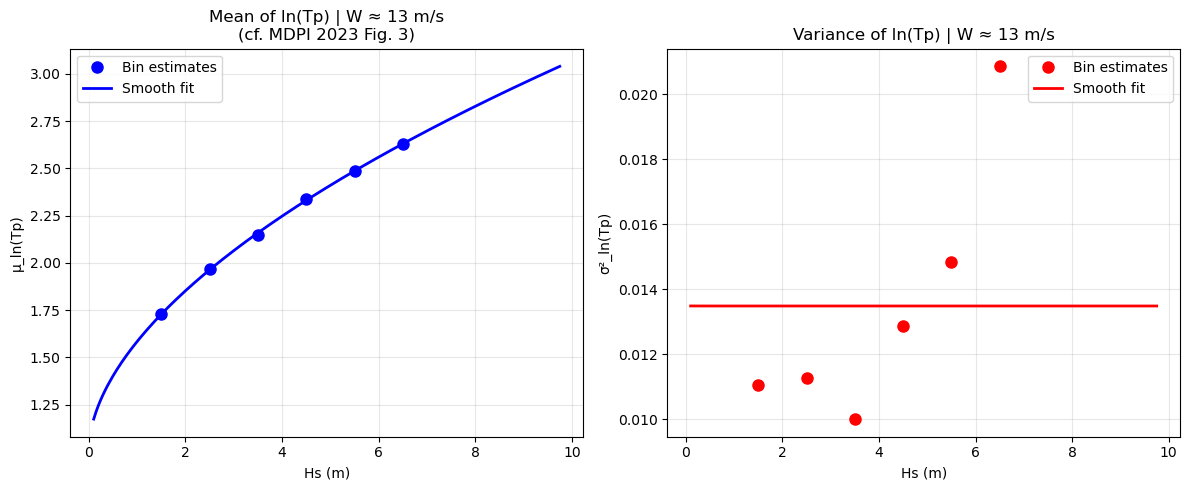

In [25]:
# Plot the smooth parameter fits for a mid-range wind bin
# Choose a W bin that has good data coverage

w_example = W_bin_centers_used[len(W_bin_centers_used)//2]  # middle bin

if w_example in lognormal_params:
    params = lognormal_params[w_example]
    Hs_plot = np.linspace(0.1, params['Hs_centers'].max() * 1.5, 200)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Mean of ln(Tp)
    mu_smooth = mu_func(Hs_plot, *params['popt_mu'])
    axes[0].plot(params['Hs_centers'], params['mu_obs'], 'bo', 
                 label='Bin estimates', markersize=8)
    axes[0].plot(Hs_plot, mu_smooth, 'b-', linewidth=2, label='Smooth fit')
    axes[0].set_xlabel('Hs (m)')
    axes[0].set_ylabel('μ_ln(Tp)')
    axes[0].set_title(f'Mean of ln(Tp) | W ≈ {w_example:.0f} m/s\n(cf. MDPI 2023 Fig. 3)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    
    # Variance of ln(Tp)
    var_smooth = var_func(Hs_plot, *params['popt_var'])
    axes[1].plot(params['Hs_centers'], params['var_obs'], 'ro', 
                 label='Bin estimates', markersize=8)
    axes[1].plot(Hs_plot, var_smooth, 'r-', linewidth=2, label='Smooth fit')
    axes[1].set_xlabel('Hs (m)')
    axes[1].set_ylabel('σ²_ln(Tp)')
    axes[1].set_title(f'Variance of ln(Tp) | W ≈ {w_example:.0f} m/s')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('lognormal_Tp_params.png', dpi=150)
    plt.show()

In [26]:
def get_lognormal_params_for_Wbin(w):
    """Find the nearest fitted W bin and return its parameter functions"""
    # Find nearest W bin center
    w_centers = np.array(list(lognormal_params.keys()))
    nearest_idx = np.argmin(np.abs(w_centers - w))
    return lognormal_params[w_centers[nearest_idx]]

# def F_Tp_given_Hs_W(t, h, w):
#     """
#     CDF of Tp given Hs and W.
#     Returns probability that peak period <= t, given wave height h and wind speed w.
#     """
#     params = get_lognormal_params_for_Wbin(w)
    
#     # Get smooth parameter values at this Hs
#     mu = mu_func(h, *params['popt_mu'])
#     sigma2 = var_func(h, *params['popt_var'])
#     sigma2 = max(sigma2, 0.001)  # enforce minimum variance as per MDPI paper
#     sigma = np.sqrt(sigma2)
    
#     # Lognormal CDF: probability that Tp <= t
#     # = probability that ln(Tp) <= ln(t)
#     # = standard normal CDF of (ln(t) - mu) / sigma
#     return stats.norm.cdf((np.log(t) - mu) / sigma)

def F_Tp_given_Hs_W(t, h, w):
    w_ctrs = np.array(list(lognormal_params.keys()))
    par    = lognormal_params[w_ctrs[np.argmin(np.abs(w_ctrs - w))]]
    mu     = mu_func(h,  *par['popt_mu'])
    sigma2 = np.clip(var_func(h, *par['popt_var']), 0.001, 0.20)
    sigma  = np.sqrt(sigma2)
    return stats.norm.cdf((np.log(t) - mu) / sigma)

In [27]:
from scipy.stats import norm
from scipy.optimize import brentq

def W_to_U1(w):
    """Transform physical wind speed to standard normal U1"""
    p = weibull_cdf(w, alpha_W, beta_W)
    p = np.clip(p, 1e-10, 1 - 1e-10)  # avoid log(0) in norm.ppf
    return norm.ppf(p)

def U1_to_W(u1):
    """Inverse: transform U1 back to physical wind speed"""
    p = norm.cdf(u1)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    # Invert Weibull CDF: W = beta * (-ln(1-p))^(1/alpha)
    return beta_W * (-np.log(1 - p))**(1/alpha_W)

def Hs_to_U2(h, w):
    """Transform physical wave height to standard normal U2 (conditional on W=w)"""
    p = F_Hs_given_W(h, w)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return norm.ppf(p)

def U2_to_Hs(u2, w):
    """Inverse: transform U2 back to physical wave height given W=w"""
    p = norm.cdf(u2)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    # Invert conditional Weibull CDF
    alpha = alpha_Hs_func(w)
    beta = beta_Hs_func(w)
    return beta * (-np.log(1 - p))**(1/alpha)

def Tp_to_U3(t, h, w):
    """Transform physical peak period to standard normal U3 (conditional on Hs=h, W=w)"""
    p = F_Tp_given_Hs_W(t, h, w)
    p = np.clip(p, 1e-10, 1 - 1e-10)
    return norm.ppf(p)

# def U3_to_Tp(u3, h, w):
#     """Inverse: transform U3 back to physical peak period given Hs=h, W=w"""
#     p = norm.cdf(u3)
#     p = np.clip(p, 1e-10, 1 - 1e-10)
#     params = get_lognormal_params_for_Wbin(w)
#     mu = mu_func(h, *params['popt_mu'])
#     sigma2 = max(var_func(h, *params['popt_var']), 0.001)
#     sigma = np.sqrt(sigma2)
#     # Invert Lognormal: Tp = exp(mu + sigma * Phi^-1(p))
#     return np.exp(mu + sigma * norm.ppf(p))

def U3_to_Tp(u3, h, w):
    w_ctrs = np.array(list(lognormal_params.keys()))
    par    = lognormal_params[w_ctrs[np.argmin(np.abs(w_ctrs - w))]]
    mu     = mu_func(h,  *par['popt_mu'])
    sigma2 = var_func(h, *par['popt_var'])
    
    # Cap sigma2 — values above 0.2 are physically unrealistic for ln(Tp)
    # The MDPI 2023 paper enforces a minimum of 0.001; 
    # we enforce a maximum of 0.2 for the same physical reasoning
    sigma2 = np.clip(sigma2, 0.001, 0.20)
    sigma  = np.sqrt(sigma2)
    
    p  = np.clip(norm.cdf(u3), 1e-10, 1 - 1e-10)
    Tp = np.exp(mu + sigma * norm.ppf(p))
    
    return np.clip(Tp, 1.0, 30.0)  # physical bounds on Tp

In [28]:
# Compute the target reliability index beta for 100-year return period
# At hourly resolution: 100 years * 8766 hours/year
K1Y_hourly = 8766  # number of hourly observations per year
return_period = 100  # years

p_exceedance = 1 / (return_period * K1Y_hourly)
beta_target = norm.ppf(1 - p_exceedance)

print(f"100-year return period probability per hour: {p_exceedance:.2e}")
print(f"Target reliability index beta: {beta_target:.4f}")
# You should get approximately 4.75

# Parametrise the sphere in U-space using spherical coordinates
# U1 = beta * cos(theta)
# U2 = beta * sin(theta) * cos(phi)
# U3 = beta * sin(theta) * sin(phi)

n_theta = 50  # resolution in polar angle (0 to pi)
n_phi = 100   # resolution in azimuthal angle (0 to 2*pi)

theta_vals = np.linspace(0.01, np.pi - 0.01, n_theta)
phi_vals = np.linspace(0, 2*np.pi, n_phi)

# Storage for the contour surface in physical space
W_contour = np.zeros((n_theta, n_phi))
Hs_contour = np.zeros((n_theta, n_phi))
Tp_contour = np.zeros((n_theta, n_phi))

print("Building contour surface - this may take a few minutes...")

for i, theta in enumerate(theta_vals):
    for j, phi in enumerate(phi_vals):
        
        # Point on the sphere in U-space
        u1 = beta_target * np.cos(theta)
        u2 = beta_target * np.sin(theta) * np.cos(phi)
        u3 = beta_target * np.sin(theta) * np.sin(phi)
        
        # Back-transform to physical space
        try:
            # Inside your contour building loop, after computing w and h:
            w = U1_to_W(u1)
            h = U2_to_Hs(u2, w)

            # Physical filters — skip implausible combinations
            if w < 1.0 or w > 40.0:
                continue
            if h <= 0 or h > 25.0 or np.isnan(h) or np.isinf(h):
                continue

            t = U3_to_Tp(u3, h, w)

            if t <= 0 or t > 30.0 or np.isnan(t) or np.isinf(t):
                continue

            W_contour[i, j]  = w
            Hs_contour[i, j] = h
            Tp_contour[i, j] = t
            
        except Exception:
            # Some points may fail numerically at extremes
            W_contour[i, j] = np.nan
            Hs_contour[i, j] = np.nan
            Tp_contour[i, j] = np.nan

print("Contour surface complete.")
print(f"\nMax W on contour:  {np.nanmax(W_contour):.1f} m/s")
print(f"Max Hs on contour: {np.nanmax(Hs_contour):.1f} m")
print(f"Max Tp on contour: {np.nanmax(Tp_contour):.1f} s")

100-year return period probability per hour: 1.14e-06
Target reliability index beta: 4.7267
Building contour surface - this may take a few minutes...
Contour surface complete.

Max W on contour:  28.7 m/s
Max Hs on contour: 14.6 m
Max Tp on contour: 30.0 s


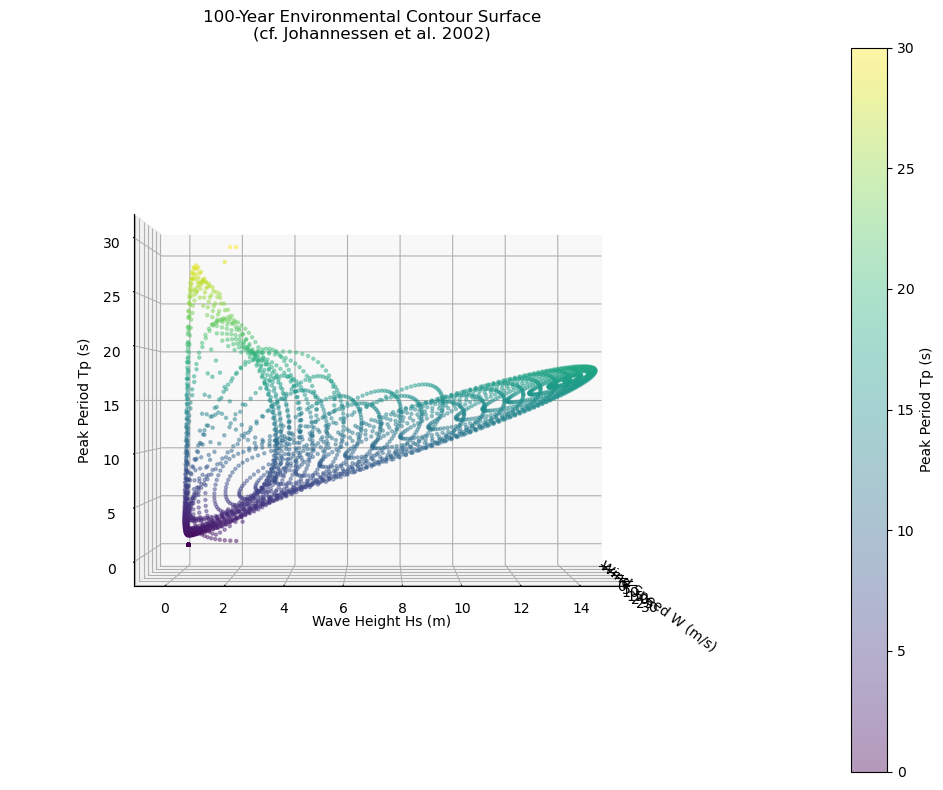

In [29]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Flatten and remove NaN values for plotting
mask = ~(np.isnan(W_contour) | np.isnan(Hs_contour) | np.isnan(Tp_contour))

sc = ax.scatter(W_contour[mask], Hs_contour[mask], Tp_contour[mask],
                c=Tp_contour[mask], cmap='viridis', 
                alpha=0.4, s=5)

plt.colorbar(sc, ax=ax, label='Peak Period Tp (s)', pad=0.1)
ax.set_xlabel('Wind Speed W (m/s)')
ax.set_ylabel('Wave Height Hs (m)')
ax.set_zlabel('Peak Period Tp (s)')
ax.set_title('100-Year Environmental Contour Surface\n(cf. Johannessen et al. 2002)')
ax.view_init(elev=0, azim=0)


plt.tight_layout()
plt.savefig('contour_surface_3D.png', dpi=150)
plt.show()

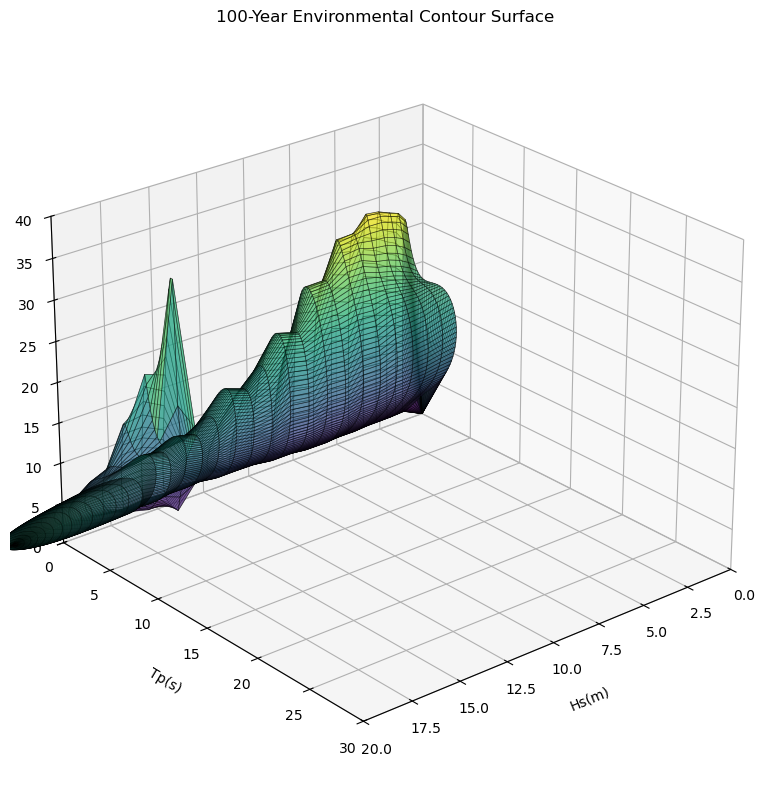

In [33]:
# Mask the arrays before passing to plot_surface
W_plot  = np.ma.masked_invalid(W_contour)
Hs_plot = np.ma.masked_invalid(Hs_contour)
Tp_plot = np.ma.masked_invalid(Tp_contour)

fig = plt.figure(figsize=(12, 8))
ax  = fig.add_subplot(111, projection='3d')

ax.plot_surface(W_plot, Hs_plot, Tp_plot,
                cmap='viridis',
                alpha=0.5,
                linewidth=0.5,
                edgecolor='k',
                rstride=1,
                cstride=1,
                clip_on=True)

ax.set_xlabel('Hs(m)',   labelpad=10)
ax.set_ylabel('Tp(s)',   labelpad=10)
ax.set_zlabel('Uw(m/s)', labelpad=10)

ax.set_xlim(0, 20)
ax.set_ylim(0, 30)
ax.set_zlim(0, 40)

# ✅ Flip Hs axis so Z-axis appears on LEFT
ax.invert_xaxis()

# Optional: ensure Tp grows "away" from Hs nicely
ax.invert_yaxis()

ax.set_title('100-Year Environmental Contour Surface')
ax.view_init(elev=25, azim=230)
plt.tight_layout()
plt.savefig('contour_3D_fixed.png', dpi=150)
plt.show()

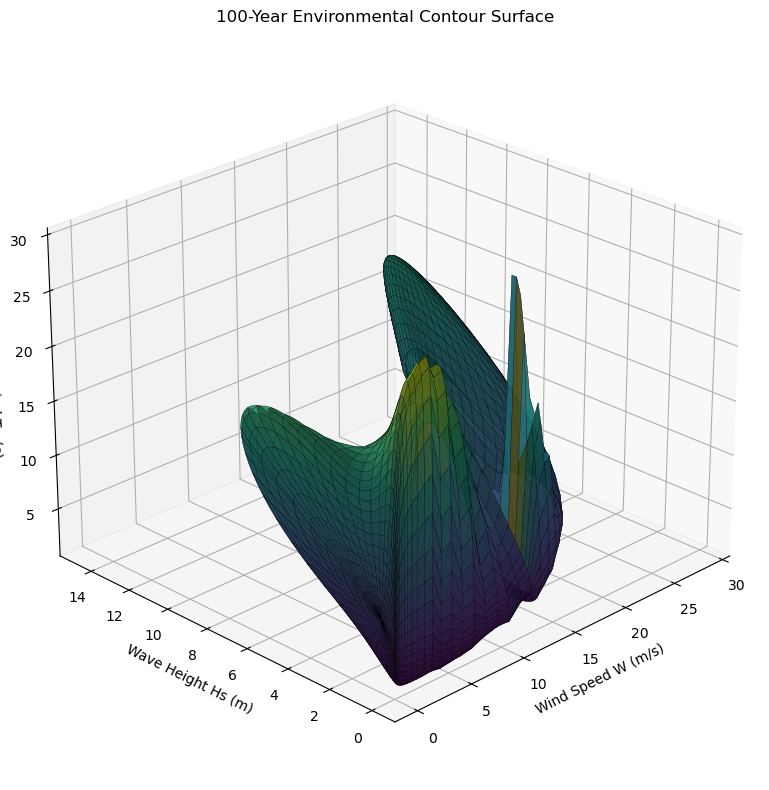

In [90]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W_contour, Hs_contour, Tp_contour,
                facecolors=plt.cm.viridis(
                    (Tp_contour - np.nanmin(Tp_contour)) /
                    (np.nanmax(Tp_contour) - np.nanmin(Tp_contour))
                ),
                alpha=0.8, linewidth=0.2, edgecolor='k')

ax.set_xlabel('Wind Speed W (m/s)')
ax.set_ylabel('Wave Height Hs (m)')
ax.set_zlabel('Peak Period Tp (s)')
ax.set_title('100-Year Environmental Contour Surface')
ax.view_init(elev=25, azim=225)
plt.tight_layout()
plt.savefig('contour_surface_smooth.png', dpi=150)
plt.show()

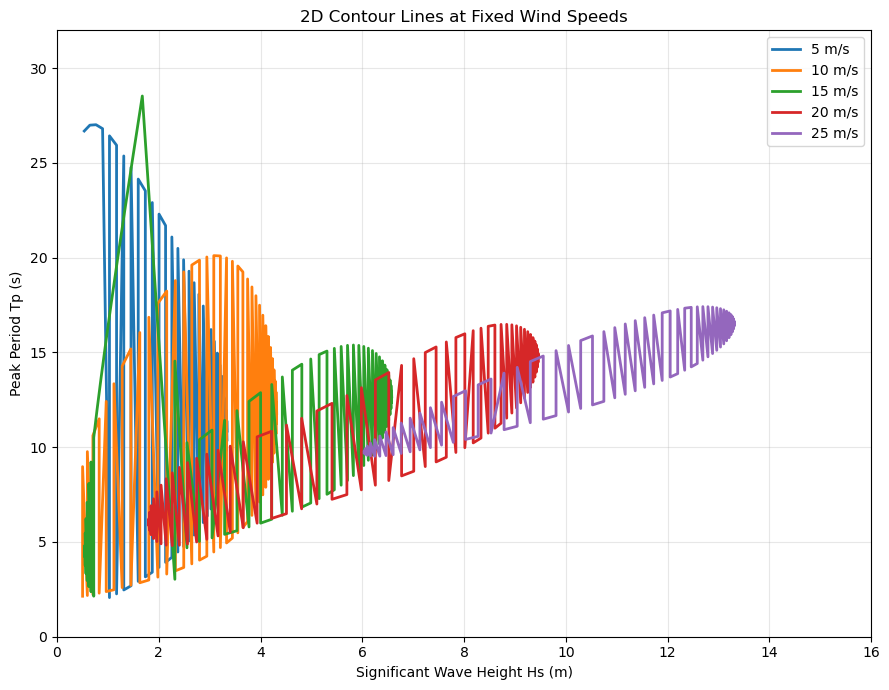

In [99]:
fig, ax = plt.subplots(figsize=(9, 7))

target_winds = [5, 10, 15, 20, 25]

for w_target in target_winds:
    # For each phi column, find the single theta where W is closest to target
    # then take that Hs and Tp value
    Hs_slice, Tp_slice = [], []
    
    for j in range(W_contour.shape[1]):
        col_W  = W_contour[:, j]
        col_Hs = Hs_contour[:, j]
        col_Tp = Tp_contour[:, j]
        
        valid = (~np.isnan(col_W) & ~np.isnan(col_Hs) & 
                 ~np.isnan(col_Tp) & (col_Hs > 0) & (col_Tp > 0))
        
        if valid.sum() < 2:
            continue
            
        # Only use the upper half of the sphere (theta < pi/2)
        # where the mapping is well-behaved
        idx = np.argmin(np.abs(col_W[valid] - w_target))
        h_val = col_Hs[valid][idx]
        t_val = col_Tp[valid][idx]
        
        # Filter out physically implausible values
        if 0.5 < h_val < 20 and 2 < t_val < 30:
            Hs_slice.append(h_val)
            Tp_slice.append(t_val)
    
    if len(Hs_slice) > 5:
        # Sort by Hs for a clean curve
        arr = np.array(sorted(zip(Hs_slice, Tp_slice)))
        ax.plot(arr[:, 0], arr[:, 1], linewidth=2, label=f'{w_target} m/s')

ax.set_xlabel('Significant Wave Height Hs (m)')
ax.set_ylabel('Peak Period Tp (s)')
ax.set_title('2D Contour Lines at Fixed Wind Speeds')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 16)
ax.set_ylim(0, 32)
plt.tight_layout()
plt.savefig('contour_2D_fixed.png', dpi=150)
plt.show()

In [100]:
# Check what lognormal parameters look like at extreme (W, Hs) combinations
# These are the combinations your contour surface is actually evaluating

print("Lognormal parameter check at extreme values:")
print("=" * 60)

test_cases = [
    (5, 2), (10, 5), (15, 8), (20, 10), (25, 13)  # (W, Hs) pairs
]

for w_test, h_test in test_cases:
    w_ctrs = np.array(list(lognormal_params.keys()))
    par = lognormal_params[w_ctrs[np.argmin(np.abs(w_ctrs - w_test))]]
    
    mu    = mu_func(h_test,  *par['popt_mu'])
    sigma2 = var_func(h_test, *par['popt_var'])
    sigma2 = max(sigma2, 0.001)
    sigma  = np.sqrt(sigma2)
    
    # What Tp does this produce at u3 = 0 (median)?
    Tp_median = np.exp(mu)
    # What Tp at u3 = beta_target (extreme end of sphere)?
    Tp_extreme = np.exp(mu + sigma * 4.75)
    
    print(f"W={w_test:4.0f} m/s, Hs={h_test:4.0f} m: "
          f"mu={mu:.3f}, sigma={sigma:.3f}, "
          f"Tp_median={Tp_median:.1f}s, "
          f"Tp_extreme={Tp_extreme:.1f}s")

Lognormal parameter check at extreme values:
W=   5 m/s, Hs=   2 m: mu=2.200, sigma=0.207, Tp_median=9.0s, Tp_extreme=24.2s
W=  10 m/s, Hs=   5 m: mu=2.571, sigma=0.151, Tp_median=13.1s, Tp_extreme=26.8s
W=  15 m/s, Hs=   8 m: mu=2.721, sigma=0.086, Tp_median=15.2s, Tp_extreme=22.9s
W=  20 m/s, Hs=  10 m: mu=2.746, sigma=0.067, Tp_median=15.6s, Tp_extreme=21.4s
W=  25 m/s, Hs=  13 m: mu=2.787, sigma=0.049, Tp_median=16.2s, Tp_extreme=20.5s


In [101]:
# Run this before rebuilding the contour
# It will catch the bad points and tell you exactly what is happening

print("Hunting for overflow points...")
print("=" * 70)

bad_count = 0
for i, theta in enumerate(theta_vals):
    for j, phi in enumerate(phi_vals):
        u1 = beta_target * np.cos(theta)
        u2 = beta_target * np.sin(theta) * np.cos(phi)
        u3 = beta_target * np.sin(theta) * np.sin(phi)
        
        try:
            w = U1_to_W(u1)
            h = U2_to_Hs(u2, w)
            
            # Flag anything suspicious
            if h > 25 or h < 0 or np.isnan(h) or np.isinf(h):
                bad_count += 1
                if bad_count <= 10:  # only print first 10
                    print(f"  BAD Hs: theta={theta:.2f}, phi={phi:.2f} -> "
                          f"u2={u2:.2f}, W={w:.1f}, Hs={h:.2e}")
                continue
            
            # Check what lognormal gives for this (w, h)
            w_ctrs = np.array(list(lognormal_params.keys()))
            par = lognormal_params[w_ctrs[np.argmin(np.abs(w_ctrs - w))]]
            mu     = mu_func(h,  *par['popt_mu'])
            sigma2 = var_func(h, *par['popt_var'])
            
            if sigma2 < 0 or sigma2 > 1 or np.isnan(sigma2) or mu > 5:
                bad_count += 1
                if bad_count <= 10:
                    print(f"  BAD Tp params: W={w:.1f}, Hs={h:.1f} -> "
                          f"mu={mu:.3f}, sigma2={sigma2:.3e}")
        except:
            pass

print(f"\nTotal bad points: {bad_count} out of {len(theta_vals)*len(phi_vals)}")

Hunting for overflow points...
  BAD Tp params: W=14.9, Hs=1.9 -> mu=1.810, sigma2=7.409e+00
  BAD Tp params: W=14.9, Hs=1.7 -> mu=1.771, sigma2=8.565e+01
  BAD Tp params: W=14.9, Hs=1.5 -> mu=1.734, sigma2=7.962e+02
  BAD Tp params: W=14.9, Hs=1.3 -> mu=1.700, sigma2=5.890e+03
  BAD Tp params: W=14.9, Hs=1.2 -> mu=1.669, sigma2=3.464e+04
  BAD Tp params: W=14.9, Hs=1.1 -> mu=1.640, sigma2=1.631e+05
  BAD Tp params: W=14.9, Hs=1.0 -> mu=1.615, sigma2=6.219e+05
  BAD Tp params: W=14.9, Hs=0.9 -> mu=1.592, sigma2=1.950e+06
  BAD Tp params: W=14.9, Hs=0.8 -> mu=1.573, sigma2=5.112e+06
  BAD Tp params: W=14.9, Hs=0.7 -> mu=1.556, sigma2=1.140e+07

Total bad points: 32 out of 5000
